# Here the comes the Selective classifiers


In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

import pickle

In [2]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [3]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [4]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = 'adult48k'
dt_name = "toy_dataset"
dt_name = "german_credit"
cf_method = 'ils'#dice or 'debug'
cf_latent = True


name_dataset = {"german_credit": "German Credit", 
                "adult48k": "Adult",
                "toy_dataset":"Toy Dataset",
                }[dt_name]
cf_results

'counterfactuals/'

In [5]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/german_credit/feature_names.csv
Loaded X_train from data/processed/german_credit/X_train.npz
Loaded y_train from data/processed/german_credit/y_train.npz
Loaded X_test from data/processed/german_credit/X_test.npz
Loaded y_test from data/processed/german_credit/y_test.npz
Loaded X_calibration from data/processed/german_credit/X_calibration.npz
Loaded y_calibration from data/processed/german_credit/y_calibration.npz


In [6]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for german_credit
Loaded random_forest model from models/german_credit/random_forest.pkl
Loaded existing random_forest model
Processing mlp for german_credit
Loaded mlp model from models/german_credit/mlp.pkl
Loaded existing mlp model
Processing xgboost for german_credit
Loaded xgboost model from models/german_credit/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for german_credit
Loaded lgbm model from models/german_credit/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


## Load the distances files

In [7]:
fname = os.path.join(cf_method,dt_name+"_ranking_latent.pkl")
fname_test = os.path.join(cf_method,dt_name+"_ranking_test_latent.pkl")

if not cf_latent:
    fname = fname.replace("_latent","")
    fname_test = fname_test.replace("_latent","")


if utl.check_file_exists(fname):
    with open(fname, "rb") as f:
        all_stats = pickle.load(f)
        print("Loaded",fname)
else:
    print("!"*6,fname, "not found")
if utl.check_file_exists(fname_test):
    with open(fname_test,'rb') as f:
        all_stats_test = pickle.load(f)
        print("Loaded",fname_test)
else:
    print("!"*6,fname_test, "not found")


Loaded ils/german_credit_ranking_latent.pkl
Loaded ils/german_credit_ranking_test_latent.pkl


In [8]:
def check_res(stats_dict = all_stats,k="mlp"):
    """this function return True if the distances related to the model k are already computed"""
    # try if the list containing the mean dists has length > 0
    try:
        print("("+str(len(stats_dict[k]['distances']['l2']['mean'])),"elements computed)")
        return len(stats_dict[k]['distances']['l2']['mean']) >= 200
    except Exception as e:
        print(e)
        return False
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(200 elements computed)
random_forest computed? True
(250 elements computed)
	 test? True
(200 elements computed)
mlp computed? True
(250 elements computed)
	 test? True
(200 elements computed)
xgboost computed? True
(250 elements computed)
	 test? True
(200 elements computed)
lgbm computed? True
(250 elements computed)
	 test? True


In [9]:

# convert all the list in the dictionary to numpy arrays
for k in models.keys():
    for metric in all_stats[k]['distances'].keys():
        for stat in ["min", "max", "mean", "std"]:
            try:
                all_stats[k]['distances'][metric][stat] = np.array(all_stats[k]['distances'][metric][stat])
            except Exception as e:
                print(e)
                print(k, metric, stat,len(all_stats[k]['distances'][metric][stat]))
                for e in all_stats[k]['distances'][metric][stat]:
                    print(e)
for k in models.keys():
    all_stats[k]['probabs'] = np.array(all_stats[k]['probabs'])
    all_stats[k]['corrects'] = np.array(all_stats[k]['corrects']).reshape(-1)
    all_stats[k]['mean_conf'] = np.array(all_stats[k]['mean_conf'])

In [10]:
# convert all the list in the dictionary to numpy arrays
for k in models.keys():
    for metric in all_stats_test[k]['distances'].keys():
        for stat in ["min", "max", "mean", "std"]:
            try:
                all_stats_test[k]['distances'][metric][stat] = np.array(all_stats_test[k]['distances'][metric][stat])
            except Exception as e:
                print(e)
                print(k, metric, stat,len(all_stats_test[k]['distances'][metric][stat]))
                for e in all_stats_test[k]['distances'][metric][stat]:
                    print(e)
for k in models.keys():
    all_stats_test[k]['probabs'] = np.array(all_stats_test[k]['probabs'])
    all_stats_test[k]['corrects'] = np.array(all_stats_test[k]['corrects']).reshape(-1)
    all_stats_test[k]['mean_conf'] = np.array(all_stats_test[k]['mean_conf'])

#### Here we import the necessary libraries for the 
# Selective classifiers


In [ ]:

#from Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss

from OLD_src.Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss
# use importlib as we have to reload the module
#importlib.reload(cfdr)
import rejectmodels.CFDistRejector as cfdr
from src.utils import compute_selective_metrics



In [12]:
focus_metrics = ['inf',
 'chebyshev',
 'l2',
 'minkowski',
 'wasserstein',
 'l1',
 'mae',
 'sqeuclidean']

In [13]:
# Selective Classifiers
# the keys are the models
# plug_in rulers
plug_in_rulers = {}
# its auxiliary dictionary
selected_plg = {}

#plug_in_rulers_auc
plug_in_rulers_auc = {}
# its auxiliary dictionary
selected_plg_auc = {}

# the l2 rejectors
l2_rejectors = {}
# its auxiliary dictionary
selected_l2r = {}

# the l2 rejectors with gamma (gamma is the distribution used to compute the quantiles)
l2_rejectors_gamma = {}
# its auxiliary dictionary
selected_l2r_gamma = {}

# now let's generalize for all the l2r based on distaces:
# since for each metric we have 3 values (min, mean, max) we will have 3 different rejectors for each metric
# keeping a named dict for each is unfeasible, so we will use a dictionary of dictionaries:
# the key will be the metric followed by the type (min, mean, max) and the value will be a dictionary with the model as key.
#  l2rejectors_distances
l2_rejectors_distances = {}
selected_l2_rejectors_distances = {}

# the values are:
# - rejection_quality_dict: the rejection quality of the model
# - plug_in_rulers: the plug-in ruler of the models
# - rejected_by_coverage: the number of samples rejected by the coverage
# - classification_quality_dict: the classification quality of the model () 
rejected_by_coverage = {}
classification_quality_dict = {}
rejection_quality_dict = {}
included_samples = {}

all_original_scores = {}
# the target coverages
target_coverages_n = 30
target_coverages = np.linspace(0.001,1,target_coverages_n-6)[::-1][1:]
target_coverages = sorted(list(set(target_coverages))+[0.5,0.9,0.95,0.99,0.01,0.05],reverse=True)
target_coverages_n = len(target_coverages)
n = len(splits['X_test'])

# initialize the dictionaries for the results
for k in models.keys():
    # Our method
    l2_rejectors[k] = cfdr.CFDistRejector(model=models[k],
                                    coverages=target_coverages)
    
    l2_rejectors_gamma[k] = cfdr.CFDistRejector(model=models[k],coverages=target_coverages)
    # The others:
    # the plug-in ruler
    plug_in_rulers[k] =  PlugInRule(model=models[k])
    # Probably I will have to change this to the version that do not refit the model
    plug_in_rulers_auc[k] = PlugInRuleAUC(model=models[k])
    all_original_scores[k] = accuracy_score(splits['y_test'], models[k].predict(splits['X_test']))
    
    # the following are the dictionaries for the results, one for each selective technique
    rejected_by_coverage[k] = {}
    classification_quality_dict[k] = {}
    rejection_quality_dict[k] = {}
    included_samples[k] = {}
    for selective_c in ["PlugInRule","PlugInRuleAUC"]:
        rejected_by_coverage[k][selective_c] = np.zeros(target_coverages_n)
        classification_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
        rejection_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
        included_samples[k][selective_c] = np.zeros(target_coverages_n)


for k in models.keys():
    l2_rejectors_distances[k] = {}
    for metric in focus_metrics:
        for m_type in ["min","max","mean"]:
            for gamma_flag in [False,True]:
                selective_c = "CFDistRejector_"+metric+"_"+m_type+("_gamma" if gamma_flag else "")
                l2_rejectors_distances[k][selective_c] = cfdr.CFDistRejector(model=models[k],
                                        coverages=target_coverages)
                                        #distance=metric,
                                        #distance_type=m_type)
                # the following are the dictionaries for the results, one for each selective technique
                rejected_by_coverage[k][selective_c] = np.zeros(target_coverages_n)
                classification_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
                rejection_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
                included_samples[k][selective_c] = np.zeros(target_coverages_n)

        

metric_dicts = {
    "rejected_by_coverage":rejected_by_coverage,
    "classification_quality_dict":classification_quality_dict,
    "rejection_quality_dict":rejection_quality_dict,
    "included_samples":included_samples
}    

In [14]:
for k in included_samples["mlp"].keys():
    print(k)#selected_l2_rejectors_distances.keys()

PlugInRule
PlugInRuleAUC
CFDistRejector_inf_min
CFDistRejector_inf_min_gamma
CFDistRejector_inf_max
CFDistRejector_inf_max_gamma
CFDistRejector_inf_mean
CFDistRejector_inf_mean_gamma
CFDistRejector_chebyshev_min
CFDistRejector_chebyshev_min_gamma
CFDistRejector_chebyshev_max
CFDistRejector_chebyshev_max_gamma
CFDistRejector_chebyshev_mean
CFDistRejector_chebyshev_mean_gamma
CFDistRejector_l2_min
CFDistRejector_l2_min_gamma
CFDistRejector_l2_max
CFDistRejector_l2_max_gamma
CFDistRejector_l2_mean
CFDistRejector_l2_mean_gamma
CFDistRejector_minkowski_min
CFDistRejector_minkowski_min_gamma
CFDistRejector_minkowski_max
CFDistRejector_minkowski_max_gamma
CFDistRejector_minkowski_mean
CFDistRejector_minkowski_mean_gamma
CFDistRejector_wasserstein_min
CFDistRejector_wasserstein_min_gamma
CFDistRejector_wasserstein_max
CFDistRejector_wasserstein_max_gamma
CFDistRejector_wasserstein_mean
CFDistRejector_wasserstein_mean_gamma
CFDistRejector_l1_min
CFDistRejector_l1_min_gamma
CFDistRejector_l1_max

In [ ]:
for jj,k in enumerate(models.keys()):
    print("Model",k)
    ###########################
    ## SELECTIVE CLASSIFIERS ##
    ###########################
    # get the plug in rule
    plug_in_rule = plug_in_rulers[k]
    #target_coverages = [.99, .75, .50, ...] 
    plug_in_rule.calibrate(splits["X_calibration"], target_coverages=target_coverages)
    # here we create an array containing levels for acceptance depending on how the selective classifiers are calibrated
    # since we used 100 target coverages, we have 101 levels of acceptance, i.e., 0, 1, 2, 3, ..., 100
    selected_plg[k] = plug_in_rule.qband(splits["X_test"])

    
    # get the plug in rule that uses the AUC
    plug_in_ruler_auc = plug_in_rulers_auc[k]
    # Here we calibrate the selective classifier that uses the AUC
    plug_in_ruler_auc.calibrate(X=splits["X_calibration"],
                                    y=splits["y_calibration"].values.reshape(-1),
                                    target_coverages=target_coverages)
    # here the bands
    selected_plg_auc[k] = plug_in_rulers_auc[k].qband(splits["X_test"])

    for specific_metric in focus_metrics:
        # get the "metric" rejector
        l2_rejector = l2_rejectors[k]
        # calibrate the rejector
        l2_rejector.calibrate(splits["X_calibration"], all_stats[k]["distances"][specific_metric]["mean"])
        # save the selected data
        selected_l2r[k] = l2_rejector.qband(splits["X_test"],all_stats_test[k]["distances"][specific_metric]["mean"])


        l2_rejectors_g = l2_rejectors_gamma[k]
        l2_rejectors_g.calibrate(splits["X_calibration"], all_stats[k]["distances"][specific_metric]["mean"],
                                use_gamma=True)
        selected_l2r_gamma[k] = l2_rejectors_g.qband(splits["X_test"],all_stats_test[k]["distances"][specific_metric]["mean"])

        print(selected_plg[k][:10],type(selected_plg[k]))
        print(selected_plg_auc[k][:10],type(selected_plg_auc[k]))
        print(selected_l2r[k][:10],type(selected_l2r[k]))
        print(selected_l2r_gamma[k][:10],type(selected_l2r_gamma[k]))


    for selective_k in metric_dicts["rejected_by_coverage"][k].keys():
        if selective_k[:len("PlugInRuleAUC")] == "PlugInRuleAUC":
            selected = selected_plg_auc[k]
            selected_c = plug_in_rulers_auc[k]
        if selective_k[:len("PlugInRule")] == "PlugInRule":
            selected = selected_plg[k]
            selected_c = plug_in_rulers[k]
        if selective_k[:len("CFDistRejector")] == "CFDistRejector":
            selected = selected_l2r[k]
            selected_c = l2_rejectors[k]
        if selective_k[len("CFDistRejector_gamma"):] == "CFDistRejector_gamma":
            selected = selected_l2r_gamma[k]
            selected_c = l2_rejectors_g
        print(type(selected_c),type(selected))
        compute_selective_metrics(model_key=k,
                                    selected_data=selected,
                                    classifier_type=selective_k,
                                    selective_classifier=selected_c,
                                    splits=splits,
                                    target_coverages=target_coverages,
                                    n=n,
                                    metric_dicts=metric_dicts)
    # now we have to iterate over the metrics and the types of distances
    selected_l2_rejectors_distances[k] = {}
    for metric in focus_metrics:
        for m_type in ["min","max","mean"]:
            selective_c = "CFDistRejector_"+metric+"_"+m_type
            l2_rejector = l2_rejectors_distances[k][selective_c]
            l2_rejector.calibrate(splits["X_calibration"], all_stats[k]["distances"][metric][m_type])
            selected_l2_rejectors_distances[k][selective_c] = l2_rejector.qband(splits["X_test"],all_stats_test[k]["distances"][metric][m_type])
    for metric in focus_metrics:
        for m_type in ["min","max","mean"]:
            selective_c = "CFDistRejector_"+metric+"_"+m_type
            compute_selective_metrics(model_key=k,
                                    selected_data=selected_l2_rejectors_distances[k])[selective_c],
                                    classifier_type=selective_c,
                                    selective_classifier=l2_rejectors_distances[k][selective_c],
                                    splits=splits,
                                    target_coverages=target_coverages,
                                    n=n,
                                    metric_dicts=metric_dicts)


Model random_forest
[12 28 28 15 28 17 12 23 16  4] <class 'numpy.ndarray'>
[22. 29. 29.  1. 29.  8.  1. 20.  7. 12.] <class 'numpy.ndarray'>
[12 28 27 13 28 17 12 24 16  1] <class 'numpy.ndarray'>
[12 27 25 13 25 18 11 24 16  1] <class 'numpy.ndarray'>
[12 28 28 15 28 17 12 23 16  4] <class 'numpy.ndarray'>
[22. 29. 29.  1. 29.  8.  1. 20.  7. 12.] <class 'numpy.ndarray'>
[12 28 27 13 28 17 12 24 16  1] <class 'numpy.ndarray'>
[12 27 25 13 25 18 11 24 16  1] <class 'numpy.ndarray'>
[12 28 28 15 28 17 12 23 16  4] <class 'numpy.ndarray'>
[22. 29. 29.  1. 29.  8.  1. 20.  7. 12.] <class 'numpy.ndarray'>
[12 27 27 14 28 17 12 23 16  1] <class 'numpy.ndarray'>
[12 25 25 14 26 19 11 24 16  3] <class 'numpy.ndarray'>
[12 28 28 15 28 17 12 23 16  4] <class 'numpy.ndarray'>
[22. 29. 29.  1. 29.  8.  1. 20.  7. 12.] <class 'numpy.ndarray'>
[12 27 27 14 28 17 12 23 16  1] <class 'numpy.ndarray'>
[12 25 25 14 26 19 11 24 16  3] <class 'numpy.ndarray'>
[12 28 28 15 28 17 12 23 16  4] <class 'nump

In [16]:
metric_dicts.keys()

dict_keys(['rejected_by_coverage', 'classification_quality_dict', 'rejection_quality_dict', 'included_samples'])

In [17]:
all_original_scores

{'random_forest': 0.752, 'mlp': 0.744, 'xgboost': 0.744, 'lgbm': 0.744}

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
# Create a custom colormap with a specific midpoint
def shiftedColorMap(cmap, start=0, midpoint=0.5, stop=1.0, name='shiftedcmap'):
    '''
    Function to offset the "center" of a colormap. Useful for
    data with a negative min and positive max and you want the
    middle of the colormap's dynamic range to be at zero.
    
    Input
    -----
      cmap : The matplotlib colormap to be altered
      start : Offset from lowest point in the colormap's range.
          Defaults to 0.0 (no lower offset). Should be between
          0.0 and 1.0.
      midpoint : The new center of the colormap. Defaults to 
          0.5 (no shift). Should be between 0.0 and 1.0.
      stop : Offset from highest point in the colormap's range.
          Defaults to 1.0 (no upper offset). Should be between
          0.0 and 1.0.
      name : Name for the new colormap
    '''
    cdict = {
        'red': [],
        'green': [],
        'blue': [],
        'alpha': []
    }
    
    # Regular index to compute the colors
    reg_index = np.linspace(start, stop, 257)
    
    # Shifted index to match the data
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, 128, endpoint=False), 
        np.linspace(midpoint, 1.0, 129, endpoint=True)
    ])
    
    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)
        
        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))
        
    newcmap = mcolors.LinearSegmentedColormap(name, cdict)
    return newcmap



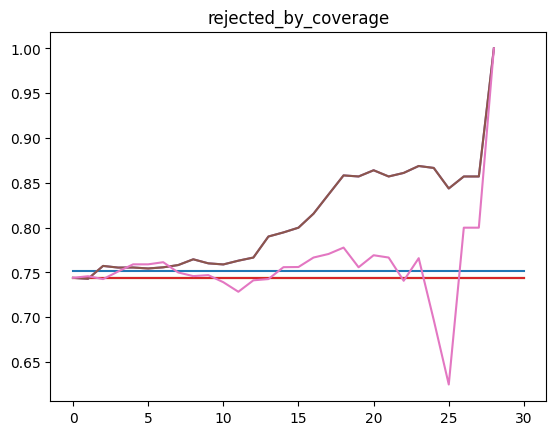

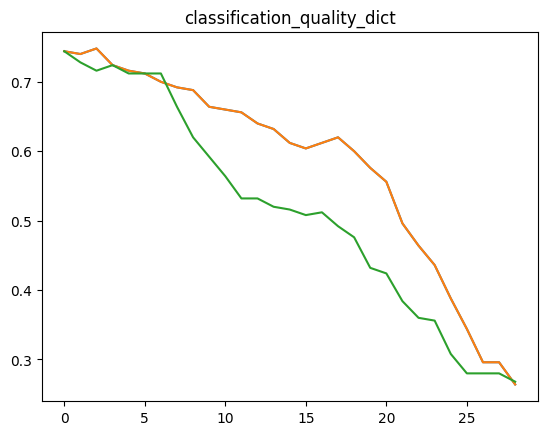

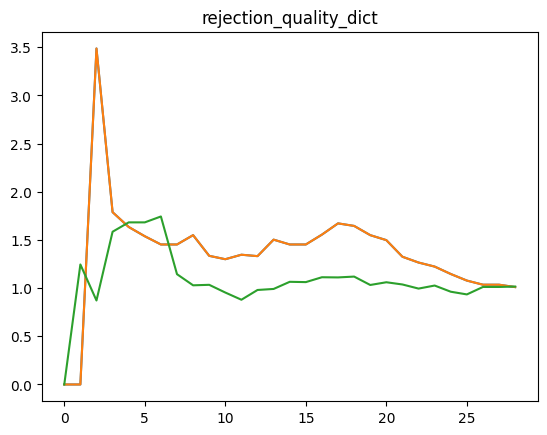

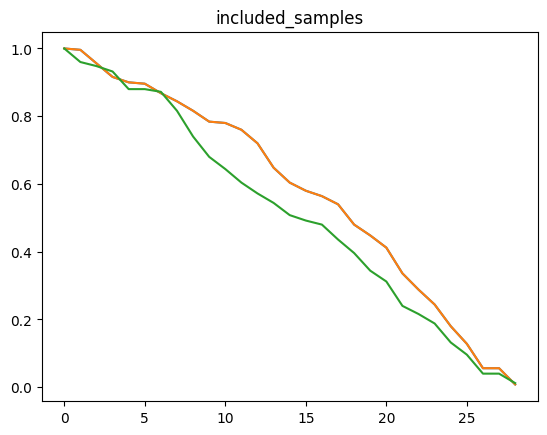

In [19]:
for m in metric_dicts.keys():
    if m=="rejected_by_coverage":
        # place horizontal line at the original bb score
        for k in models.keys():
            plt.plot([0,30],[all_original_scores[k],all_original_scores[k]],label="Original "+k)
        
    plt.plot(metric_dicts[m]["mlp"]["PlugInRuleAUC"],label="PlugInRuleAUC")
    plt.plot(metric_dicts[m]["mlp"]["PlugInRule"],label="PlugInRule")
    plt.plot(metric_dicts[m]["mlp"]["CFDistRejector_l2_mean"],label="CFDistRejector_l2_mean")
    plt.title(m)
    plt.show()


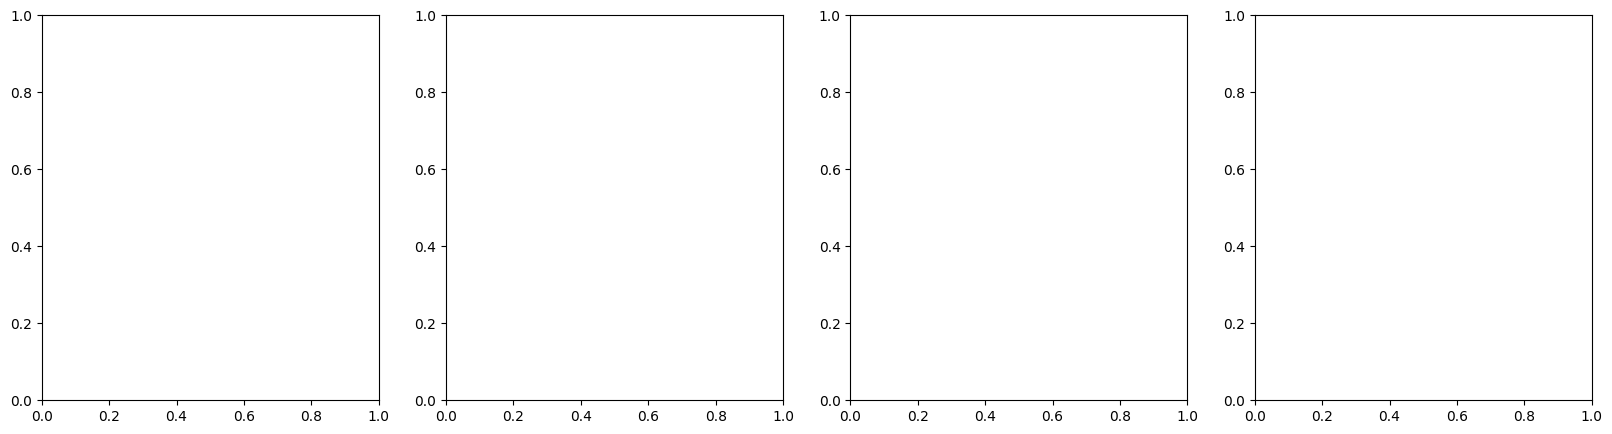

In [20]:
## here I can have the results for the selective classifiers for the dataset dt_name, and the method cf_method
# just for the sake of the example, let's print the results for the first model in a fancy way:
# we plot the best selective classifier for each target coverage
k = list(models.keys())[0]
# make a big figure to plot the results
fig,ax = plt.subplots(1,4,figsize=(20,5))
ax = ax.flatten()
# for each model we plot the results
dataframes = {}
selective_metric = "rejected_by_coverage"

for k in models.keys():
    
    metric_dicts[selective_metric][k]
    df = pd.DataFrame()
    # place each k,v in a dataframe
    for chey,val in metric_dicts[selective_metric][k].items():
        df[chey] = val
    # invert the rows and columns
    df = df.T
    # rename the columns as the target coverages
    df.columns = target_coverages
    dataframes[k] = df

vmedian = min(all_original_scores.values())
vmax = 1
vmin = min([df.values.min() for df in dataframes.values()]+[vmedian])
cmap_base = sns.color_palette("BrBG_r", as_cmap=True)
# now change the diverging map cmap_base so that the mid point (white) corresponds to the median value
#cmap = shiftedColorMap(cmap_base, midpoint=vmedian,vmin=vmin, vmax=vmax)

# Calculate the midpoint in the range from vmin to vmax that corresponds to vmedian
midpoint = (vmedian - vmin) / (vmax - vmin)

# Use the BrBG_r colormap as the base
cmap_base = sns.color_palette("BrBG_r", as_cmap=True)

# Create a new colormap with the shifted midpoint
custom_cmap = shiftedColorMap(cmap_base, midpoint=midpoint)
#cmap = sns.diverging_palette(220, 20, as_cmap=True)



In [21]:
# dataframes[k]


random_forest [10, 4, 22, 46, 16, 34, 40, 12]
(50, 14) (50, 14) 8
mlp [30, 26, 0, 1, 2, 8, 42, 36]
(50, 14) (50, 14) 0
xgboost [0, 1, 4, 10, 22, 46, 16, 2]
(50, 14) (50, 14) 0
lgbm [0, 1, 4, 10, 6, 12, 2, 8]
(50, 14) (50, 14) 0


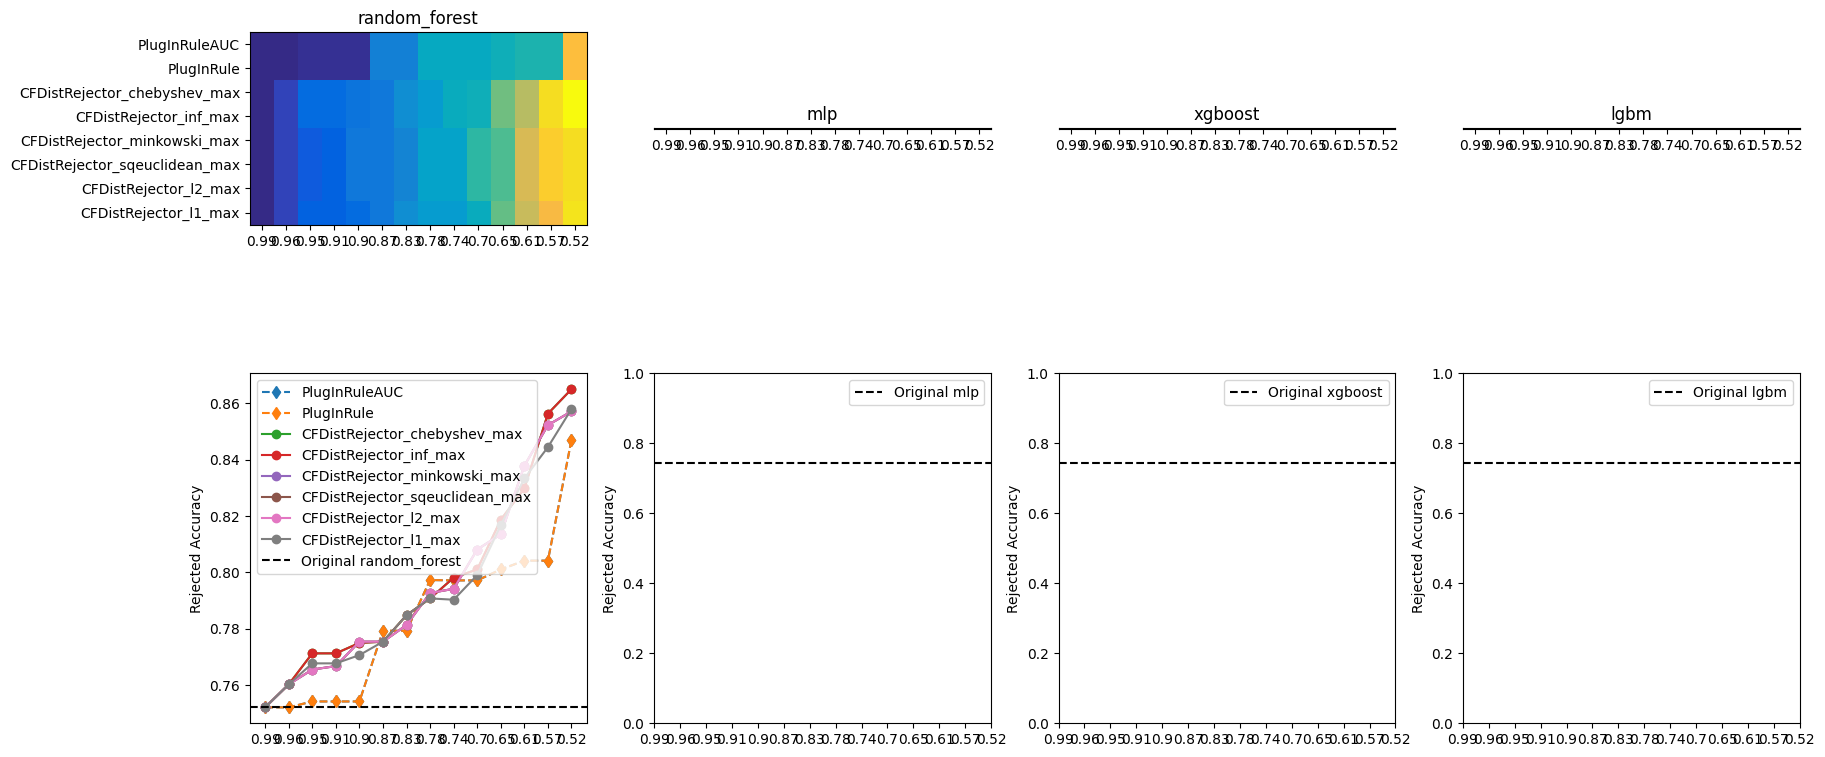

In [32]:
fig,ax = plt.subplots(2,4,figsize=(20,10))
ax = ax.flatten()
# let's place the gamma sampled ones lower, so, excluded the first 2, we take the even ones
plug_in_and_auc = [0,1]
gamma_ones = [i for i in range(2,len(dataframes[k].index)) if i%2==1]
not_gamma = [i for i in range(2,len(dataframes[k].index)) if i%2==0]
top_k = 2+6
for i,k in enumerate(models.keys()):
    #top_policies = plug_in_and_auc+not_gamma+gamma_ones
    # select only up to the 50 target coverages
    df = dataframes[k].copy().iloc[:,:target_coverages_n//2]
    # let's take the real bests:
    # plug_in_and_auc are the first two, we will keep them.
    # However we will make the sum of the rows and take only the top 5
    fake_auc = df.values.sum(axis=1).argsort()[::-1][:top_k]
    top_policies = list(fake_auc)
    print(k,top_policies)
    if 0 not in top_policies:
        top_policies = [0]+top_policies[:-1]
    else:
        # place it as the first anyway
        top_policies = [0]+top_policies.pop(top_policies.index(0))
    if 1 not in top_policies:
        top_policies = [1]+top_policies[:-1]
    else:
        # place it as the second anyway
        top_policies = top_policies[0]+[1]+top_policies.pop(top_policies.index(1))[1:]
    top_policies_names = dataframes[k].index[top_policies]
    #df = dataframes[k].copy().iloc[top_policies,:target_coverages_n//2]
    minimum = df.values.min()
    
    vmax = df.values.max()
    custom_cmap = shiftedColorMap(cmap_base, 
                                   midpoint=midpoint)
    # ok use a classic cmap
    custom_cmap = fplt.parula

    print(df.shape,df.values.shape,len(top_policies_names))
    #sns.heatmap(df,ax=ax[i],cmap=custom_cmap,vmin=minimum,vmax=1)
    ax[i].imshow(df.values[top_policies,:],cmap=custom_cmap,vmin=minimum,vmax=vmax)
    
    ax[i].set_title(k)
    
        
    # now plot them as lines
    for j in top_policies:
        if j in [0,1]:
            ls = '--'
            marker = 'd'
        else:
            ls = '-'
            marker='o'
        label = df.index[j]
        ax[4+i].plot(df.values[j,:],label=label,marker=marker,ls=ls)
    ax[4+i].axhline(all_original_scores[k],label="Original "+k,color='k',ls='--')
    if True:#i==0: #it's the first plot
        
        ax[i].set_yticks(np.array([i for i in range(len(top_policies_names))]),top_policies_names)
        # set the y label
        ax[4+i].set_ylabel("Rejected Accuracy")
    
    ax[i].set_xticks(range(target_coverages_n//2),[str(round(e,2)) for e in df.columns],rotation=0)
    ax[4+i].set_xticks(range(target_coverages_n//2),[str(round(e,2)) for e in df.columns],rotation=0)
    ax[4+i].legend()


In [25]:
markers = ["o","d","s","v","^","p"]*100
colors = ["blue","red","green","purple"]*100
markers = markers*100

In [26]:
from typing import Any, Dict
from OLD_src.Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss
from OLD_src.MyLoreSA.metrics import nonrejected_accuracy, classification_quality, rejection_quality, rejection_classification_report


Model random_forest Accuracy: 0.752
Model mlp Accuracy: 0.744
Model xgboost Accuracy: 0.744
Model lgbm Accuracy: 0.744


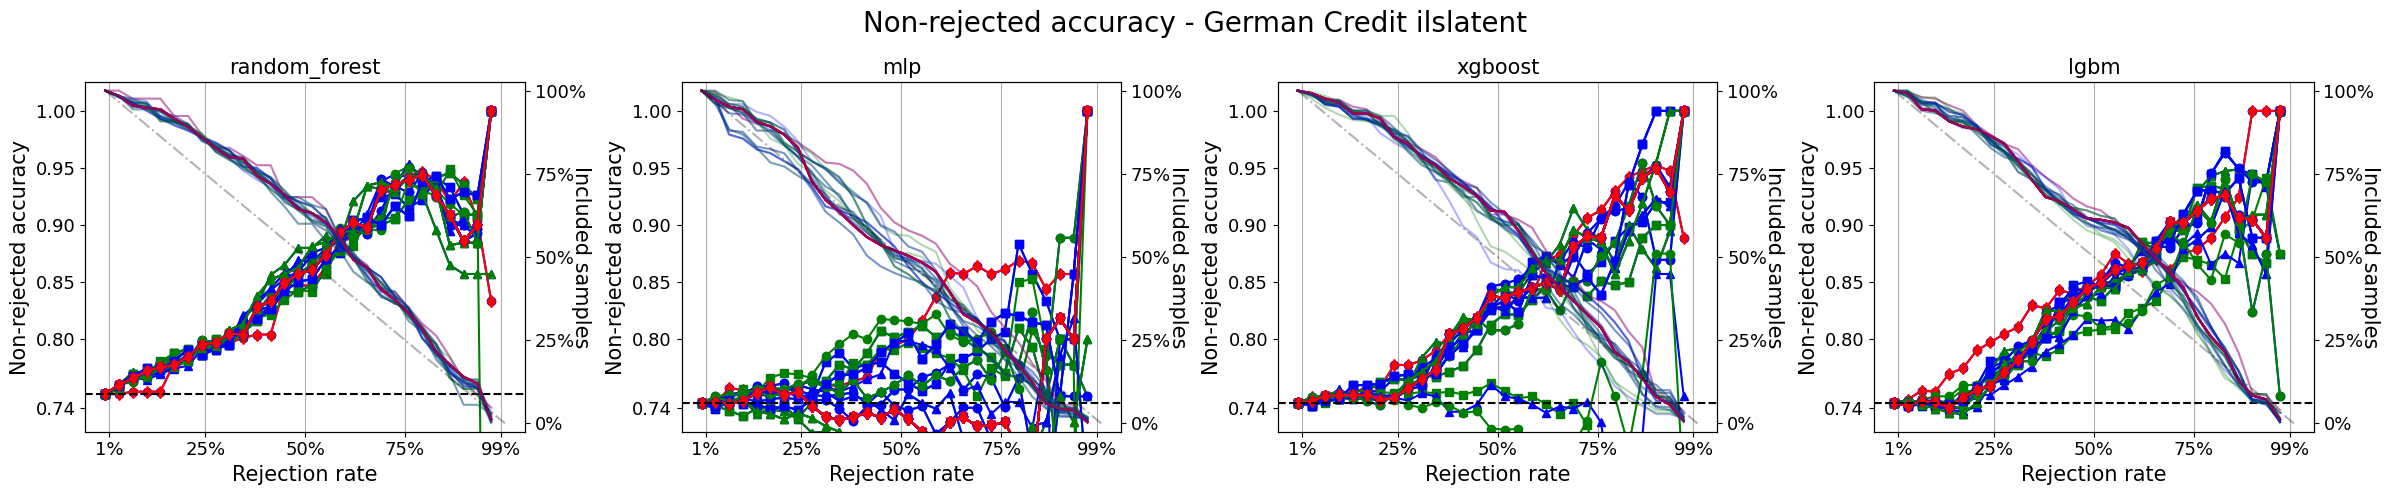

In [29]:
#iterate over the models

fig, ax = plt.subplots(1,#len(models.keys())//2,
                       len(models.keys()),
                       figsize=(24,5))
ax = ax.flatten()
for jj,k in enumerate(models.keys()):
    axx2 = ax[jj].twinx()
    for selective_k,marker,color in zip(rejected_by_coverage[k].keys(),
                                        markers,
                                        colors):
        rejected_acc = rejected_by_coverage[k][selective_k]
        ax[jj].plot(np.arange(len(rejected_acc))/len(rejected_acc), rejected_acc, 
                    label=selective_k.replace("_gamma"," $_\gamma$"),
                    marker=marker,
                    color=color)

        ax[jj].set_title(k,fontsize=15)
        ax[jj].set_xlabel('Rejection rate', fontsize=15)
        # set the xticks to be 1%, 25 % , 50 %, 75 % and 99
        ax[jj].set_xticks([0.01,0.25,0.5,0.75,0.99])
        # add the percentage sign
        ax[jj].set_xticklabels(['1%','25%','50%','75%','99%'], fontsize=13)
        ax[jj].set_ylabel('Non-rejected accuracy', fontsize=15)
        ax[jj].grid()
        # plot the 0% rejection accuracy
        low_y_lim = -0.05
        low_y_lim = min(all_original_scores.values())
        ax[jj].set_ylim(low_y_lim-0.025,1.025)
        # get the ticks for the y axis of ax, and be sure to not exceed 1.0 as tick
        ax[jj].set_yticks(np.linspace(low_y_lim,1.0,6).round(2))
        # set the font of the y ticks
        ax[jj].yaxis.set_tick_params(labelsize=13)
        # get the twin axis
        
        # plot the number of included samples in the classification
        included_samp = included_samples[k][selective_k]
        axx2.plot(np.arange(target_coverages_n)/target_coverages_n, included_samp, 
                    label="% samples",
                    
                    color=color,
                    linestyle="-",alpha=0.3)

    axx2.set_ylabel("Included samples",fontsize=15,rotation=270)
    # set the yticks to be 0, 25 % , 50 %, 75 % and 100 %
    axx2.set_yticks([0,0.25,0.5,0.75,1])
    # add the percentage sign
        # to be ure add the "target" rejection rate as a diagonal line
    axx2.set_yticklabels(['0%','25%','50%','75%','100%'], fontsize=13)
    # place grid on the y axis
    ax[jj].grid()
    axx2.set_ylim(-0.025,1.025)
    #ax[jj].set_xlim(-0.05,.5)
    ax[jj].axhline(all_original_scores[k],linestyle="--",
        color="black",label=k)
    axx2.plot([0,1],[1,0],color="black",linestyle="-.",alpha=0.3)
    #ax[jj].legend(loc="lower center")
    # plot the y grid
    ax[jj].grid(axis='y')
plt.suptitle("Non-rejected accuracy - " + name_dataset +" "+ cf_method + ("latent" if cf_latent else ""),fontsize=20)
plt.tight_layout()
for k in models.keys():
    # roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    # print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(4)
    print(f"Model {k} Accuracy: {acc}")
plt.show()

## Add Statistical tests to the Selective classifiers


In [ ]:
import scikit_posthocs as sp
import scipy.stats as ss
from decimal import Decimal
def create_df_and_check(methods_names,
                        values,
                        title="",
                        title_size=18,
                        show=True,
                        exp="",
                        metrica='',
                        dt_name ='dt_name',vmin=0,vmax=0.4,hmargin=0.1,vertica_image_size=5):
    '''methods_names is a list of the names of the methods.
    values is a list containing the values of the methods. It has as many columns as the number of methods and as many rows as the number of metric domanins. For example if the metrics rre Frob and Kendalltau, the values will have 2 rows and as many rows as the number of proposals.'''
    # create the dataframe
    df = pd.DataFrame(values,columns=methods_names)
    # compute the ranks for the friedman test
    ranks = df.rank(axis=1)
    # check the shape of the ranks to be analogous to the methods_names
    assert ranks.values.shape[1] == len(methods_names), "the ranks have a different number of columns than the methods names"

    #print(ranks.shape,"shape of the ranks")
    #print(df.head())
    #print(ranks.head())
    
    # Convert p-value to scientific notation
    # now check the friedman test
    if len(values)>=3:
        _, p = ss.friedmanchisquare(*values)
        cd = sp.posthoc_nemenyi_friedman(ranks)
    else:
        raise("not enough values to perform the friedman test")
    if p < 0.05:
        #print("the differences are significant\n"+title)
        # prepare the CD diagram
        if  len(values)>=2:
            fig,ax = plt.subplots(2,1,figsize=(10,vertica_image_size))
            axes = ax.flatten()

            ranks_res,colors_res = remap_names(ranking_df=ranks,colors_dict=colors_dict)
            if (np.sum(cd<0.05)>0).any():
                # plot the CD diagram using the ranks and the critical difference
                cd.columns = [res_d[col] for col in cd.columns]
                # here it gives an error because the adjiance matrix is not symmetric
                # to solve this we need to make the adjiance matrix symmetric
                # the index of the adjiance matrix should be the same as the columns
                cd.index = cd.columns
                label_props = {"fontsize":title_size-1}
                print("plotting CD diagram")
                # all in black  
                black_colors = {k:"black" for k in colors_res.keys()}
                black_colors = colors_res
                axes[1].set_xlim(1,len(methods_names))
                # set the xlim to be in the 1-len(methods_names)-1 range
                # (there is never a first and last method that is significantly different)
                sp.critical_difference_diagram(ranks_res.T.mean(axis=1),cd,label_props=label_props,color_palette=black_colors,ax=axes[1],
                                               text_h_margin=hmargin)

            else:
                # now write big on the image "no significant difference"
                axes[1].text(0.5,0.5,"no significant difference",fontsize=20)
            # plot the boxplot of the values getting the pathces from the colors dictionary
            if metrica != "$ShapGap_{L2}$":
                values= -values
                df = -df
                if metrica != "Faithfulness":
                    ylab = "Similarity"
                
                else:
                    ylab = "Faithfulness"
            else:
                ylab = "Distance"
            
            axes[0].grid(axis='y')
            print("plotting boxplot")
            print(df)
            #for j in range(len(df.columns)):
            #    axes[0].scatter(j*np.ones(len(df)),df.iloc[:,j])
            #axes[0].boxplot(values,patch_artist=True,showfliers=True)
            sns.boxenplot(data=df,ax=axes[0],palette=[colors_dict[k] for k in df.columns],fill=False)

            '''
            pathches = axes[0].boxplot(values,patch_artist=True,showfliers=True)
            for pathch, mn in zip(pathches['boxes'],methods_names):
                c = colors[mn]
                
                pathch.set_facecolor(c)
            '''
            # set the xticks to be the names of the methods
            axes[0].set_xticks(np.arange(len(methods_names)),ranks_res.columns,rotation=30,fontsize=15)
            # set the title of the boxplot
            #axes[0].set_title("Boxplot of the values\n"+dt_name+" "+" ".join([str(elemento) for elemento in exp]),fontsize=title_size)
            # the y grid
            # set the y label
            axes[0].set_ylabel(ylab,fontsize=title_size)
            # set ylim
            #axes[0].set_ylim(vmin,vmax)

            
            p = np.sum(cd<0.05)
        print(cd.round(2))
        # remove the diagonal of the cd matrix as a new cd1 matrix
        cd1 = cd.copy()
        np.fill_diagonal(cd1.values,0)
        # do the sum
        s = np.sum(cd1.values,axis=1)
        print(s)
        # get the index of the lowest value that is lower than 0.05*len(methods_names)
        idx = np.where(s<0.05*len(methods_names))[0]
        print(s[idx])
        if len(idx)>0:
            p = min(s[idx])
        
            # transform the p value to scientific notation like 0.3E-3
            p_str = "{:.3E}".format(Decimal(str(p)))
            title += " - p value "+p_str
        else:
            title += " - No significant difference"

        plt.suptitle(title,fontsize=title_size)
        plt.tight_layout()
        
    print()

In [ ]:
res_d = {k:k.replace("_"," ") for k in rejected_by_coverage["mlp"].keys()}
colors_dict = {k:colors[i] for i,k in enumerate(rejected_by_coverage["mlp"].keys())}

In [ ]:
def remap_names(ranking_df,colors_dict):
    '''this function is used to remap the names of the methods to more meaningful names. It is used to plot the critical difference diagram.
    '''
    res_colors = {res_d[k]:v for k,v in colors_dict.items()}
    # rankin_df is a dataframe that has as many columns called as the methods 
    # to remap the names of the methods we use the res_d dictionary
    ranking_df.columns = [res_d[col] for col in ranking_df.columns]
    print(res_colors,"res_colors")
    print(ranking_df.columns,"columns of the ranking_df")
    return ranking_df,res_colors

In [ ]:
k = "lgbm"
for j,m in enumerate(focus_metrics):
    method_names = list(rejected_by_coverage[k].keys())[4+j*3:4+6+(j+1)*3]
    values = np.array([rejected_by_coverage[k][m] for m in method_names]).T

    # now compute the statistical tests
    create_df_and_check(methods_names=method_names,
                        values=-values,
                        title="Non-rejected accuracy",
                        show=True,
                        exp="",
                        metrica="Non-rejected accuracy",
                        dt_name = dt_name,
                        vmin=0.5,vmax=1,hmargin=0.1,vertica_image_size=5)
    plt.show()
    input()

# TODO add other metrics